<a href="https://colab.research.google.com/github/marynatarasevych/ML_Study/blob/main/Tarasevych_%22HW_2_2_%D0%9B%D0%BE%D0%B3%D1%96%D1%81%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B7_scikit_learn_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
#from sklearn.linear_model import LinearRegression
#from sklearn.metrics import root_mean_squared_error, r2_score
#import statsmodels.api as sm

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', lambda x: f'{x:,.2f}'.replace(',', ' '))

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/Train Data.csv")
train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15 779 985.00,Nwankwo,678.00,France,Male,29.00,4.00,0.00,3.00,1.00,0.00,180 626.36,0.00
1,1,15 650 086.00,Ch'in,687.00,France,Female,34.00,1.00,0.00,2.00,0.00,1.00,63 736.17,0.00
2,2,15 733 602.00,Thompson,682.00,France,Female,52.00,6.00,0.00,3.00,0.00,0.00,179 655.87,1.00
3,3,15 645 794.00,Macleod,753.00,Germany,Male,44.00,6.00,83 347.25,2.00,1.00,0.00,161 407.48,0.00
4,4,15 633 840.00,Hsia,544.00,Germany,Female,55.00,0.00,107 747.57,1.00,1.00,0.00,176 580.86,1.00


In [4]:
train_df, val_df = train_test_split(train, test_size=0.25, random_state=42, stratify=train["Exited"])

In [5]:
print(train["Exited"].value_counts(normalize=True))
print(train_df["Exited"].value_counts(normalize=True))
print(val_df["Exited"].value_counts(normalize=True))

Exited
0.00   0.80
1.00   0.20
Name: proportion, dtype: float64
Exited
0.00   0.80
1.00   0.20
Name: proportion, dtype: float64
Exited
0.00   0.80
1.00   0.20
Name: proportion, dtype: float64


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [6]:
cols_to_drop = ["id", "CustomerId", "Surname", "Exited"]
input_cols = train_df.drop(columns=cols_to_drop).columns.tolist()
target_col = 'Exited'

In [7]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11250 entries, 8263 to 1292
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               11250 non-null  int64  
 1   CustomerId       11250 non-null  float64
 2   Surname          11250 non-null  object 
 3   CreditScore      11250 non-null  float64
 4   Geography        11250 non-null  object 
 5   Gender           11250 non-null  object 
 6   Age              11250 non-null  float64
 7   Tenure           11250 non-null  float64
 8   Balance          11250 non-null  float64
 9   NumOfProducts    11250 non-null  float64
 10  HasCrCard        11250 non-null  float64
 11  IsActiveMember   11250 non-null  float64
 12  EstimatedSalary  11250 non-null  float64
 13  Exited           11250 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.3+ MB


In [9]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [10]:
categorical_cols

['Geography', 'Gender']

In [11]:
train_inputs['Gender'].value_counts()

,count
Gender,
Male,6449
Female,4801


In [12]:
Gender = {'Male': 0, 'Female': 1}
train_inputs['Gender_Type'] = train_inputs['Gender'].map(Gender)
val_inputs['Gender_Type'] = val_inputs['Gender'].map(Gender)

In [13]:
categorical_cols.remove('Gender')

In [14]:
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '25-35', '35-45', '45-55', '55-65', '65+']

train_inputs['Age_Group'] = pd.cut(train_inputs['Age'], bins=bins, labels=labels)
val_inputs['Age_Group'] = pd.cut(val_inputs['Age'], bins=bins, labels=labels)

In [15]:
categorical_cols = categorical_cols + ['Age_Group']
categorical_cols

['Geography', 'Age_Group']

In [16]:
imputer_cat = SimpleImputer(strategy = 'most_frequent')

In [17]:
imputer_cat.fit(train_inputs[categorical_cols])

SimpleImputer(strategy='most_frequent')

In [18]:
train_inputs[categorical_cols] = imputer_cat.transform(train_inputs[categorical_cols])
val_inputs[categorical_cols] = imputer_cat.transform(val_inputs[categorical_cols])

In [19]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [20]:
encoder.fit(train_inputs[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [21]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
print(encoded_cols)

['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Age_Group_18-25', 'Age_Group_25-35', 'Age_Group_35-45', 'Age_Group_45-55', 'Age_Group_55-65', 'Age_Group_65+']


In [22]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

In [23]:
train_inputs = train_inputs.drop(columns=categorical_cols + ['Gender'])
val_inputs = val_inputs.drop(columns=categorical_cols + ['Gender'])

In [24]:
numeric_cols = numeric_cols + ['Gender_Type']
numeric_cols

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Gender_Type']

In [25]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Type
count,11 250.00,11 250.00,11 250.00,11 250.00,11 250.00,11 250.00,11 250.00,11 250.00,11 250.00
mean,658.99,37.69,5.02,42 952.89,1.59,0.79,0.49,117 904.96,0.43
std,72.12,8.14,2.78,59 923.39,0.53,0.41,0.50,45 553.03,0.49
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00
25%,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83 155.87,0.00
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123 587.94,0.00
75%,709.00,42.00,7.00,109 863.19,2.00,1.00,1.00,156 774.94,1.00
max,850.00,72.00,10.00,209 767.31,4.00,1.00,1.00,199 992.48,1.00


In [26]:
?SimpleImputer


In [27]:
imputer_num = SimpleImputer(strategy = 'median')

In [28]:
imputer_num.fit(train_inputs[numeric_cols])

SimpleImputer(strategy='median')

In [29]:
train_inputs[numeric_cols] = imputer_num.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer_num.transform(val_inputs[numeric_cols])

In [30]:
scaler = MinMaxScaler()

In [31]:
cols_to_exclude = ['HasCrCard', 'IsActiveMember', 'Gender_Type']
scaler_cols = [col for col in numeric_cols if col not in cols_to_exclude]
scaler_cols

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

In [32]:
scaler.fit(train_inputs[scaler_cols])

MinMaxScaler()

In [33]:
train_inputs[scaler_cols] = scaler.transform(train_inputs[scaler_cols])
val_inputs[scaler_cols] = scaler.transform(val_inputs[scaler_cols])

In [34]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Type
count,11 250.00,11 250.00,11 250.00,11 250.00,11 250.00,11 250.00,11 250.00,11 250.00,11 250.00
mean,0.54,0.36,0.50,0.20,0.20,0.79,0.49,0.59,0.43
std,0.17,0.15,0.28,0.29,0.18,0.41,0.50,0.23,0.49
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.41,0.26,0.30,0.00,0.00,1.00,0.00,0.42,0.00
50%,0.55,0.35,0.50,0.00,0.33,1.00,0.00,0.62,0.00
75%,0.66,0.44,0.70,0.52,0.33,1.00,1.00,0.78,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [35]:
train_inputs.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Type,Geography_France,Geography_Germany,Geography_Spain,Age_Group_18-25,Age_Group_25-35,Age_Group_35-45,Age_Group_45-55,Age_Group_55-65,Age_Group_65+
8263,0.63,0.26,0.50,0.62,0.00,1.00,1.00,0.43,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
14199,0.48,0.26,0.40,0.57,0.00,1.00,0.00,0.89,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
1856,0.59,0.07,0.40,0.00,0.33,1.00,1.00,0.81,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
3013,0.65,0.56,0.30,0.00,0.33,1.00,0.00,0.60,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
8266,0.63,0.31,0.70,0.00,0.33,1.00,0.00,0.50,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00


In [36]:
val_inputs.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Type,Geography_France,Geography_Germany,Geography_Spain,Age_Group_18-25,Age_Group_25-35,Age_Group_35-45,Age_Group_45-55,Age_Group_55-65,Age_Group_65+
1855,0.27,0.20,0.90,0.57,0.00,0.00,0.00,0.28,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
1273,0.40,0.43,0.30,0.59,0.00,1.00,0.00,0.88,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
5414,0.45,0.24,0.70,0.00,0.00,1.00,1.00,0.75,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
10923,0.40,0.70,0.30,0.00,1.00,1.00,0.00,0.51,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
5835,0.76,0.44,0.50,0.00,0.00,1.00,1.00,0.91,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00


**Опис передобробки**
1) видалення колонок `id`, `CustomerId` та `Surname`:
- `CustomerId` - по умові задачі
- `id` та `Surname`- не мають інформаційного обгрунтування

2) Меппінг та кодування категоріальних данних:
-  gender - 'Male': 0, 'Female': 1 - перетворення бінарної категорії в числову
- створення груп для age - '18-25', '25-35', '35-45', '45-55', '55-65', '65+'- різні групи користувачів по віку можуть мати різні поведінкові характеристики
- onehot для 'Geography' та 'Age Group' - перетворення категоріальних змінних в числові

3) Масштабування числових ознак, значення яких не від 0 до 1:
- 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary' - для приведення в один масштаб (від 0 до 1)

4) В наданих train даних пропущених немає. Але вони можуть бути на test. Тому виконую заповнення за допомогою SimpleImputer
- для категоріальних данних вибрана стратегія - most_frequent, тобто найчастіше
- для числових данних вибрана стратегія - median для ігнорування викидів (хоча для балансу це може бути не найкращим варіантом, тут краще було б поставти 0. Але в цій моделі вже не додавала)

5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [37]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (11250, 18)
train_targets: (11250,)
val_inputs: (3750, 18)
val_targets: (3750,)


In [38]:
!pip install pyarrow --quiet

In [47]:
output_dir = '/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle'
os.makedirs(output_dir, exist_ok=True)

train_inputs.to_parquet(os.path.join(output_dir, 'train_inputs.parquet'))
train_targets.to_frame().to_parquet(os.path.join(output_dir, 'train_targets.parquet'))
val_inputs.to_parquet(os.path.join(output_dir, 'val_inputs.parquet'))
val_targets.to_frame().to_parquet(os.path.join(output_dir, 'val_targets.parquet'))

print(os.listdir(output_dir))

['Train Data.csv', 'Test Data.csv', 'Sample Submission.csv', 'train_inputs.parquet', 'train_targets.parquet', 'val_inputs.parquet', 'val_targets.parquet']


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [52]:
X_train = pd.read_parquet('train_inputs.parquet')
X_val = pd.read_parquet('val_inputs.parquet')

y_train = pd.read_parquet('train_targets.parquet')['Exited']
y_val = pd.read_parquet('val_targets.parquet')['Exited']

In [80]:
print(X_train.columns.tolist())
print(X_train.dtypes)

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Gender_Type', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Age_Group_18-25', 'Age_Group_25-35', 'Age_Group_35-45', 'Age_Group_45-55', 'Age_Group_55-65', 'Age_Group_65+']
CreditScore          float64
Age                  float64
Tenure               float64
Balance              float64
NumOfProducts        float64
HasCrCard            float64
IsActiveMember       float64
EstimatedSalary      float64
Gender_Type          float64
Geography_France     float64
Geography_Germany    float64
Geography_Spain      float64
Age_Group_18-25      float64
Age_Group_25-35      float64
Age_Group_35-45      float64
Age_Group_45-55      float64
Age_Group_55-65      float64
Age_Group_65+        float64
dtype: object


In [81]:
print(list(X_train.columns) == list(X_val.columns))

True


In [53]:
from sklearn.linear_model import LogisticRegression

In [54]:
model = LogisticRegression(solver='liblinear')

In [55]:
model.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [56]:
train_preds = model.predict(X_train)

In [57]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.98597334, 0.01402666],
       [0.58157242, 0.41842758],
       [0.99031156, 0.00968844],
       ...,
       [0.99383493, 0.00616507],
       [0.84159723, 0.15840277],
       [0.95222673, 0.04777327]])

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [71]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

In [60]:
confusion_matrix(y_train, train_preds)

array([[8604,  357],
       [ 988, 1301]])

In [64]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 88.04%


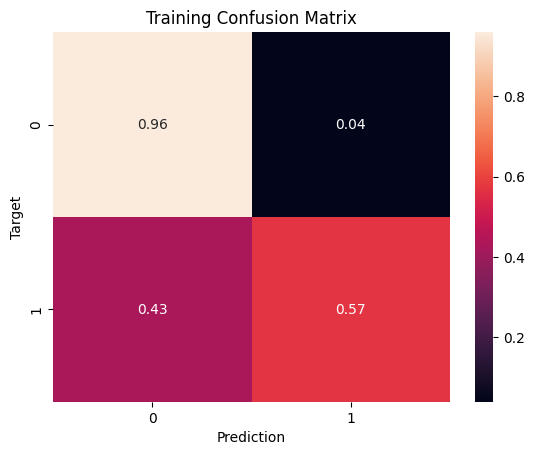

In [69]:
train_preds = predict_and_plot(X_train, y_train, 'Training')

Accuracy: 87.60%


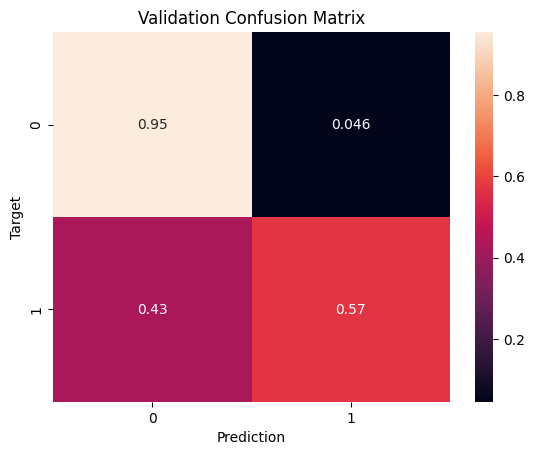

In [70]:
val_preds = predict_and_plot(X_val, y_val, 'Validation')

In [ ]:
def get_f1_score(inputs, targets, name=''):
  preds = model.predict(inputs)

  f1_score_ = f1_score(targets, preds)
  print(f"F1 score {name}: {f1_score_:.2f}%")

In [75]:
get_f1_score(X_train, y_train, 'Training')
get_f1_score(X_val, y_val, 'Validation')

F1 score Training: 0.66%
F1 score Validation: 0.65%


In [78]:
from sklearn.metrics import roc_curve, auc

def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.89


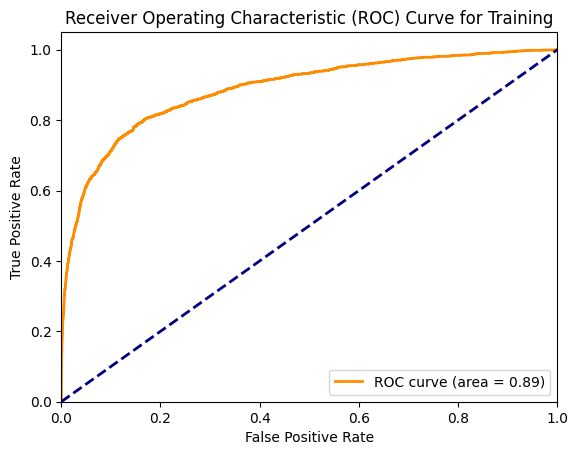

AUROC for Validation: 0.89


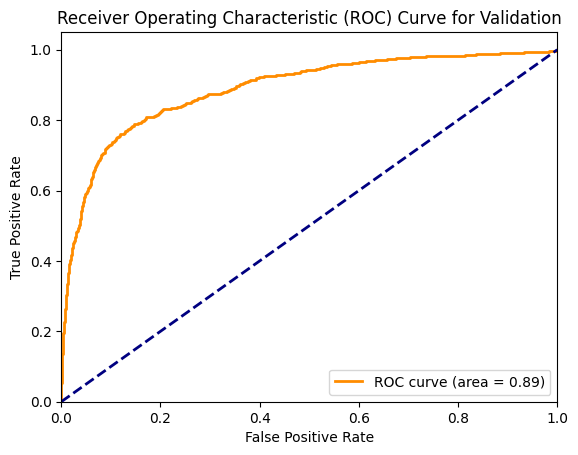

In [79]:
compute_auroc_and_build_roc(X_train, y_train, 'Training')
compute_auroc_and_build_roc(X_val, y_val, 'Validation')

In [84]:
from sklearn.metrics import precision_score, recall_score

def get_metrics(inputs, targets, name=''):
    preds = model.predict(inputs)
    probs = model.predict_proba(inputs)[:, 1]

    return {
        'Dataset': name,
        'Accuracy': accuracy_score(targets, preds),
        'Precision (class 1)': precision_score(targets, preds),
        'Recall (class 1)': recall_score(targets, preds),
        'F1 Score (class 1)': f1_score(targets, preds),
        'AUROC': roc_auc_score(targets, probs)
    }

metrics_df = pd.DataFrame([
    get_metrics(X_train, y_train, 'Training'),
    get_metrics(X_val, y_val, 'Validation')
]).set_index('Dataset').round(3)

metrics_df

,Accuracy,Precision (class 1),Recall (class 1),F1 Score (class 1),AUROC
Dataset,,,,,
Training,0.88,0.79,0.57,0.66,0.89
Validation,0.88,0.76,0.57,0.65,0.89


**Висновок**:

Модель непогано працює, має Accuracy 0,88. Проте recall = 0.57 — модель пропускає 43% клієнтів, які насправді пішли, помилково класифікуючи їх як "залишились". Це виникає через дизбаланс класу

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [85]:
majority_class = y_train.value_counts().idxmax()
print(majority_class)

0.0


In [86]:
train_majority_preds = np.full(shape=y_train.shape, fill_value=majority_class)
val_majority_preds = np.full(shape=y_val.shape, fill_value=majority_class)

In [87]:
train_majority_acc = accuracy_score(y_train, train_majority_preds)
val_majority_acc = accuracy_score(y_val, val_majority_preds)

print(f"Majority class Accuracy (Training): {train_majority_acc:.4f}")
print(f"Majority class Accuracy (Validation): {val_majority_acc:.4f}")

Majority class Accuracy (Training): 0.7965
Majority class Accuracy (Validation): 0.7965


In [88]:
comparison_df = pd.DataFrame({
    'Model': ['Majority Class (baseline)', 'Logistic Regression'],
    'Train Accuracy': [train_majority_acc, accuracy_score(y_train, train_preds)],
    'Validation Accuracy': [val_majority_acc, accuracy_score(y_val, val_preds)]
})

comparison_df

,Model,Train Accuracy,Validation Accuracy
0,Majority Class (baseline),0.80,0.80
1,Logistic Regression,0.88,0.88


**Висновок**

baseline моделі - 0,8 (без навчання моделі, а просто завжди передбачувати 0)

Моя модель має Accuracy 0,88, що всього на 8 п.п. вище. Це показує, що моя модель насправді не дуже класно прогнозує клас `Exited`

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [89]:
import joblib

In [95]:
model_bank_exited = {
    'model': model,
    'imputer_num': imputer_num,
    'imputer_cat': imputer_cat,
    'scaler': scaler,
    'scaler_cols': scaler_cols,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

In [96]:
joblib.dump(model_bank_exited, 'model_bank_exited.joblib')

['model_bank_exited.joblib']

In [97]:
model_2 = joblib.load('model_bank_exited.joblib')

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [112]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):

# 1. Видаляємо непотрібні ідентифікатори
    cols_to_drop = ['id', 'CustomerId', 'Surname']
    input_df = input_df.drop(columns=[c for c in cols_to_drop if c in input_df.columns])
# 2. Gender → Gender_Type
    Gender = {'Male': 0, 'Female': 1}
    input_df['Gender_Type'] = input_df['Gender'].map(Gender)
# 3. Age → AgeGroup
    bins = [18, 25, 35, 45, 55, 65, 100]
    labels = ['18-25', '25-35', '35-45', '45-55', '55-65', '65+']
    input_df['Age_Group'] = pd.cut(input_df['Age'], bins=bins, labels=labels)
# 4. Дістаємо збережені об'єкти
    imputer_cat = model_2['imputer_cat']
    imputer_num = model_2['imputer_num']
    scaler = model_2['scaler']
    scaler_cols = model_2['scaler_cols']
    encoder = model_2['encoder']
    numeric_cols = model_2['numeric_cols']
    categorical_cols = model_2['categorical_cols']
    encoded_cols = model_2['encoded_cols']
    model = model_2['model']
# 5. imputer_cat + encoder на категоріальних колонках
    input_df[categorical_cols] = imputer_cat.transform(input_df[categorical_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
# 6. imputer_num + scaler на числових колонках
    input_df[numeric_cols] = imputer_num.transform(input_df[numeric_cols])
    input_df[scaler_cols] = scaler.transform(input_df[scaler_cols])

    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [113]:
predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, train[:5])

array([0.00550268, 0.03025217, 0.53671821, 0.34645347, 0.98592327])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [107]:
test_raw_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/Test Data.csv")
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15 594 796.00,Chu,584.00,Germany,Male,30.00,2.00,146 053.66,1.00,1.00,1.00,157 891.86
1,15001,15 642 821.00,Mazzi,551.00,France,Male,39.00,5.00,0.00,2.00,1.00,1.00,67 431.28
2,15002,15 716 284.00,Onyekachi,706.00,France,Male,43.00,8.00,0.00,2.00,1.00,0.00,156 768.45
3,15003,15 785 078.00,Martin,717.00,Spain,Male,45.00,3.00,0.00,1.00,1.00,1.00,166 909.87
4,15004,15 662 955.00,Kenechukwu,592.00,Spain,Male,43.00,8.00,0.00,2.00,1.00,1.00,143 681.97


In [109]:
test_raw_df['Exited'] = predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, test_raw_df)
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15 594 796.00,Chu,584.00,Germany,Male,30.00,2.00,146 053.66,1.00,1.00,1.00,157 891.86,0.06
1,15001,15 642 821.00,Mazzi,551.00,France,Male,39.00,5.00,0.00,2.00,1.00,1.00,67 431.28,0.04
2,15002,15 716 284.00,Onyekachi,706.00,France,Male,43.00,8.00,0.00,2.00,1.00,0.00,156 768.45,0.14
3,15003,15 785 078.00,Martin,717.00,Spain,Male,45.00,3.00,0.00,1.00,1.00,1.00,166 909.87,0.18
4,15004,15 662 955.00,Kenechukwu,592.00,Spain,Male,43.00,8.00,0.00,2.00,1.00,1.00,143 681.97,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15 642 997.00,Chukwumaobim,639.00,Spain,Male,38.00,10.00,0.00,2.00,1.00,1.00,49 637.65,0.02
9996,24996,15 739 271.00,Clements,678.00,Spain,Male,39.00,9.00,0.00,2.00,1.00,1.00,142 513.50,0.03
9997,24997,15 756 743.00,Chidiebere,774.00,France,Male,30.00,9.00,0.00,2.00,1.00,0.00,4 861.72,0.02
9998,24998,15 680 167.00,Yermakova,595.00,France,Male,38.00,6.00,144 875.79,1.00,1.00,0.00,126 469.09,0.14


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [114]:
sample_submission = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/Sample Submission.csv")

In [116]:
sample_submission['Exited'] = test_raw_df['Exited']
sample_submission

,id,Exited
0,15000,0.06
1,15001,0.04
2,15002,0.14
3,15003,0.18
4,15004,0.05
...,...,...
9995,24995,0.02
9996,24996,0.03
9997,24997,0.02
9998,24998,0.14


In [118]:
sample_submission.to_csv('/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/submission_log_reg.csv', index=False)

In [119]:
submission_log_reg = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/submission_log_reg.csv")
submission_log_reg

,id,Exited
0,15000,0.06
1,15001,0.04
2,15002,0.14
3,15003,0.18
4,15004,0.05
...,...,...
9995,24995,0.02
9996,24996,0.03
9997,24997,0.02
9998,24998,0.14
